# **AirBlocks: Next Generation Block Based Puzzle Games Through Computer Vision Based on Hand Gesture Tracking**

**Import Library**

In [1]:
import cv2
import pygame
import random
import mediapipe as mp

print("Import success!")

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html
Import success!


**Setup Color and Screen**

In [2]:
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GRAY = (200, 200, 200)
BLUE = (50, 150, 255)
RED = (255, 50, 50)
GREEN = (50, 255, 50)
CYAN = (50, 255, 255)
MAGENTA = (255, 50, 255)
YELLOW = (255, 255, 50)
ORANGE = (255, 150, 50)
PURPLE = (150, 50, 255)
PINK = (255, 105, 180)
LIME = (150, 255, 50)
TEAL = (0, 128, 128)
BROWN = (139, 69, 19)
NAVY = (0, 0, 128)

SCREEN_WIDTH = 850
SCREEN_HEIGHT = 750
GRID_SIZE = 8
CELL_SIZE = 55
GRID_OFFSET_X = (SCREEN_WIDTH - (GRID_SIZE * CELL_SIZE)) // 2
GRID_OFFSET_Y = 50

**Setup Matrix**

In [3]:
ALL_SHAPES = [
    
    # 1.SQUARE
    {"matrix": [[1]], "color": RED},                               # 1x1
    {"matrix": [[1, 1], [1, 1]], "color": GREEN},                  # 2x2
    {"matrix": [[1, 1, 1], [1, 1, 1], [1, 1, 1]], "color": BLUE},  # 3x3

    # 2.LINE
    {"matrix": [[1, 1]], "color": CYAN},                           # 1x2 Horizontal
    {"matrix": [[1], [1]], "color": CYAN},                         # 2x1 Vertikal
    {"matrix": [[1, 1, 1]], "color": MAGENTA},                     # 1x3 Horizontal
    {"matrix": [[1], [1], [1]], "color": MAGENTA},                 # 3x1 Vertikal
    {"matrix": [[1, 1, 1, 1]], "color": YELLOW},                   # 1x4 Horizontal
    {"matrix": [[1], [1], [1], [1]], "color": YELLOW},             # 4x1 Vertikal

    # 3. Block "T"
    # T (4 Block)
    {"matrix": [[1, 1, 1], [0, 1, 0]], "color": ORANGE},           # T Normal (bawah)
    {"matrix": [[0, 1, 0], [1, 1, 1]], "color": ORANGE},           # T Terbalik (atas)
    {"matrix": [[1, 0], [1, 1], [1, 0]], "color": ORANGE},         # T Kiri
    {"matrix": [[0, 1], [1, 1], [0, 1]], "color": ORANGE},         # T Kanan

    # T (5 Block)
    {"matrix": [[1, 1, 1], [0, 1, 0], [0, 1, 0]], "color": PURPLE},# T Besar Normal
    {"matrix": [[0, 1, 0], [0, 1, 0], [1, 1, 1]], "color": PURPLE},# T Besar Terbalik
    {"matrix": [[1, 0, 0], [1, 1, 1], [1, 0, 0]], "color": PURPLE},# T Besar Kiri
    {"matrix": [[0, 0, 1], [1, 1, 1], [0, 0, 1]], "color": PURPLE},# T Besar Kanan

    # ==========================================
    # 4.Block "L"
    # L (3 Block)
    {"matrix": [[1, 0], [1, 1]], "color": PINK},                   # L 3-blok Kiri Bawah
    {"matrix": [[0, 1], [1, 1]], "color": PINK},                   # L 3-blok Kanan Bawah
    {"matrix": [[1, 1], [1, 0]], "color": PINK},                   # L 3-blok Kiri Atas
    {"matrix": [[1, 1], [0, 1]], "color": PINK},                   # L 3-blok Kanan Atas

    # L (4 Block | L and J)
    {"matrix": [[1, 0], [1, 0], [1, 1]], "color": LIME},           # L Normal
    {"matrix": [[1, 1, 1], [1, 0, 0]], "color": LIME},             # L Tidur Atas
    {"matrix": [[1, 1], [0, 1], [0, 1]], "color": LIME},           # L Terbalik
    {"matrix": [[0, 0, 1], [1, 1, 1]], "color": LIME},             # L Tidur Bawah

    {"matrix": [[0, 1], [0, 1], [1, 1]], "color": TEAL},           # J Normal (Cermin L)
    {"matrix": [[1, 0, 0], [1, 1, 1]], "color": TEAL},             # J Tidur Bawah
    {"matrix": [[1, 1], [1, 0], [1, 0]], "color": TEAL},           # J Terbalik
    {"matrix": [[1, 1, 1], [0, 0, 1]], "color": TEAL},             # J Tidur Atas

    # L (5 Block (3x3))
    {"matrix": [[1, 0, 0], [1, 0, 0], [1, 1, 1]], "color": BROWN}, # L Besar Kiri Bawah
    {"matrix": [[0, 0, 1], [0, 0, 1], [1, 1, 1]], "color": BROWN}, # L Besar Kanan Bawah
    {"matrix": [[1, 1, 1], [1, 0, 0], [1, 0, 0]], "color": BROWN}, # L Besar Kiri Atas
    {"matrix": [[1, 1, 1], [0, 0, 1], [0, 0, 1]], "color": BROWN}, # L Besar Kanan Atas

    # 5.Block "S" and "Z" (Zig-zag)
    # S and Z (4 Block)
    {"matrix": [[0, 1, 1], [1, 1, 0]], "color": NAVY},             # S Horizontal
    {"matrix": [[1, 0], [1, 1], [0, 1]], "color": NAVY},           # S Vertikal
    {"matrix": [[1, 1, 0], [0, 1, 1]], "color": NAVY},             # Z Horizontal (Cermin S)
    {"matrix": [[0, 1], [1, 1], [1, 0]], "color": NAVY},           # Z Vertikal
]

SPAWN_CENTERS = [(200, 615), (400, 615), (600, 615)]

**Hand Landmarks**

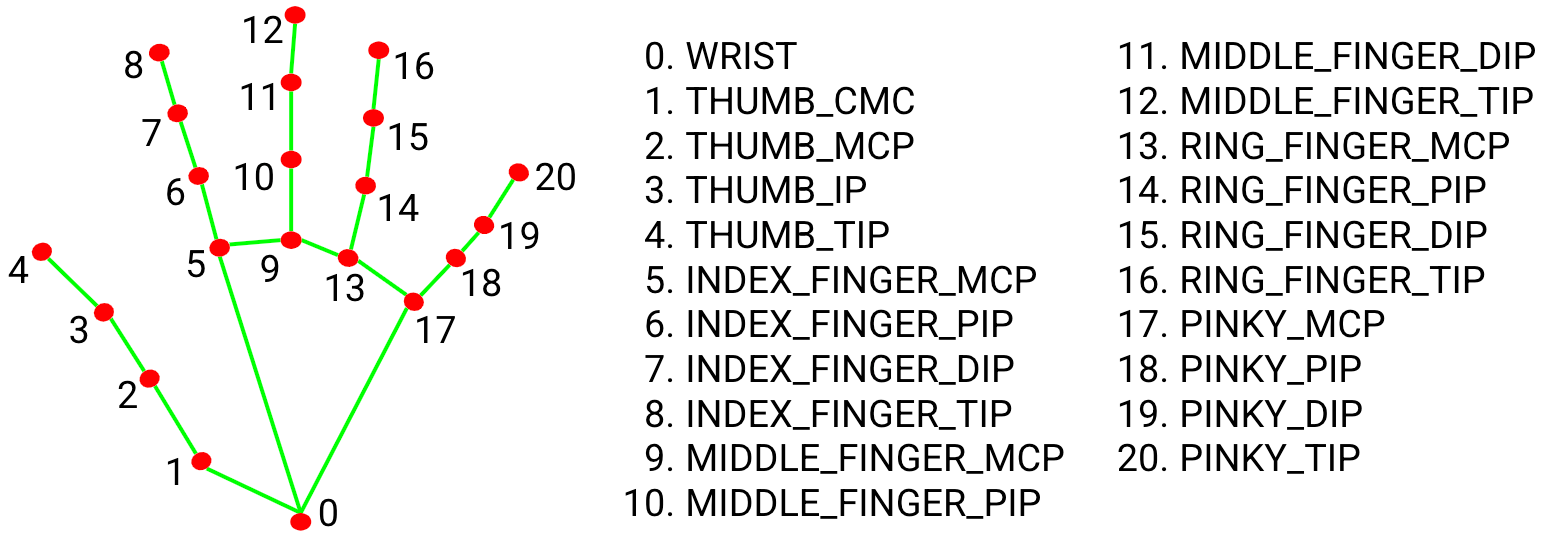

Initialization Mediapipe Hand Tracking

In [4]:
import time
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Tasks API — requires hand_landmarker.task model in the same folder.
# Download: https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.7,
    min_tracking_confidence=0.7,
)
hand_landmarker = vision.HandLandmarker.create_from_options(options)

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(0,17),(17,18),(18,19),(19,20),
]

def draw_hand_landmarks_on_frame(frame, hand_landmarks):
    h, w, _ = frame.shape
    for s, e in HAND_CONNECTIONS:
        cv2.line(frame,
                 (int(hand_landmarks[s].x * w), int(hand_landmarks[s].y * h)),
                 (int(hand_landmarks[e].x * w), int(hand_landmarks[e].y * h)),
                 (0, 255, 0), 2)
    for lm in hand_landmarks:
        cv2.circle(frame, (int(lm.x * w), int(lm.y * h)), 4, (0, 0, 255), -1)

Logic of checking whether the hand is clenched (to grab) or open (to drop).

In [5]:
def get_hand_status(hand_landmarks):
    finger_tips = [8, 12, 16, 20]
    finger_pips = [6, 10, 14, 18]
    fingers_folded = 0
    for tip, pip in zip(finger_tips, finger_pips):
        if hand_landmarks[tip].y > hand_landmarks[pip].y:
            fingers_folded += 1
    return "CLOSED" if fingers_folded >= 3 else "OPEN"

def get_cursor_position(hand_landmarks):
    x = int(hand_landmarks[9].x * SCREEN_WIDTH)
    y = int(hand_landmarks[9].y * SCREEN_HEIGHT)
    return x, y

**Grid & Block Logic**

Grid Logic

In [6]:
def create_empty_grid(): #Create an 8x8 matrix containing the number 0
    return [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

def draw_grid(surface, grid): #Drawing a checkered board and blocks that are locked inside it
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            rect = pygame.Rect(
                GRID_OFFSET_X + col * CELL_SIZE, 
                GRID_OFFSET_Y + row * CELL_SIZE, 
                CELL_SIZE, CELL_SIZE
            )
            pygame.draw.rect(surface, GRAY, rect, 1) # Border line
            
            if grid[row][col] != 0:
                pygame.draw.rect(surface, grid[row][col] , rect)
                pygame.draw.rect(surface, BLACK, rect, 1)

# Drwaing shape
def draw_shape(surface, matrix, start_x, start_y, color):
    rows = len(matrix)
    cols = len(matrix[0])
    offset_x = (cols * CELL_SIZE) // 2
    offset_y = (rows * CELL_SIZE) // 2
    
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                rect_x = start_x - offset_x + (c * CELL_SIZE)
                rect_y = start_y - offset_y + (r * CELL_SIZE)
                rect = pygame.Rect(rect_x, rect_y, CELL_SIZE, CELL_SIZE)
                pygame.draw.rect(surface, color, rect)
                pygame.draw.rect(surface, BLACK, rect, 1) # Black side line

# Generate 3 random blocks
def generate_3_options():
    options = []
    for center in SPAWN_CENTERS:
        shape_data = random.choice(ALL_SHAPES)
        options.append({
            "matrix": shape_data["matrix"],
            "color": shape_data["color"],
            "base_x": center[0],
            "base_y": center[1],
            "is_alive": True 
        })
    return options

Game Logic

In [7]:
def snap_to_grid(cursor_x, cursor_y): #Converts the free cursor coordinates to column and row indices in the Grid
    col = (cursor_x - GRID_OFFSET_X) // CELL_SIZE
    row = (cursor_y - GRID_OFFSET_Y) // CELL_SIZE
    return row, col

def is_placement_valid(grid, matrix, start_row, start_col):
    rows = len(matrix)
    cols = len(matrix[0])
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                target_row = start_row + r
                target_col = start_col + c
                if target_row < 0 or target_row >= GRID_SIZE or target_col < 0 or target_col >= GRID_SIZE:
                    return False
                if grid[target_row][target_col] != 0:
                    return False
    return True

def place_block_on_grid(grid, matrix, start_row, start_col, color):
    rows = len(matrix)
    cols = len(matrix[0])
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                grid[start_row + r][start_col + c] = color

def check_and_clear_lines(grid): 
    #Place to record the full row and column indexes
    full_rows = []
    full_cols = []
    
    # 1. CHECK HORIZONTAL (Row)
    for row in range(GRID_SIZE):
        if all(cell != 0 for cell in grid[row]):
            full_rows.append(row)
            
    # 2. CHECK VERTICAL (Column)
    for col in range(GRID_SIZE):
        if all(grid[row][col] != 0 for row in range(GRID_SIZE)):
            full_cols.append(col)
            
    lines_cleared = len(full_rows) + len(full_cols)
    
    # 3. DELETE EXECUTION (Concurrent)
    # Delete Row
    for row in full_rows:
        grid[row] = [0 for _ in range(GRID_SIZE)]
        
    # Delete Column
    for col in full_cols:
        for row in range(GRID_SIZE):
            grid[row][col] = 0

    return lines_cleared * 100 #100 point per line

def is_game_over(grid, available_blocks):
    for block in available_blocks:
        if block["is_alive"]:
            matrix = block["matrix"]
            for r in range(GRID_SIZE):
                for c in range(GRID_SIZE):
                    if is_placement_valid(grid, matrix, r, c):
                        return False 
                        
    if any(b["is_alive"] for b in available_blocks):
        return True 
        
    return False

**Run Game**

Initialize Pygame & Camera

In [8]:
pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("AirBlocks: CV Hand Tracking Blocks Game")
clock = pygame.time.Clock()

font = pygame.font.SysFont("Poppins", 27)
go_font = pygame.font.SysFont("Poppins", 60)
btn_font = pygame.font.SysFont("Poppins", 30)

cap = cv2.VideoCapture(1)

Setup Game

In [9]:
grid_board = create_empty_grid()
score = 0
cursor_x, cursor_y = SCREEN_WIDTH // 2, SCREEN_HEIGHT // 2 # Default cursor position
current_gesture = "OPEN"

available_blocks = generate_3_options()
held_block_index = -1

spawn_area_rect = pygame.Rect(SCREEN_WIDTH//2 - CELL_SIZE//2, SCREEN_HEIGHT - 100, CELL_SIZE, CELL_SIZE)

Main Loop

In [10]:
game_state = "PLAYING"

retry_rect = pygame.Rect(270, 350, 140, 60)
exit_rect = pygame.Rect(430, 350, 140, 60)

running = True
while running:
    #A. EVENT HANDLING (Exit Button)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            
    #B.OPENCV & MEDIAPIPE PROCESSING
    success, frame = cap.read()
    if not success:
        continue
        
    frame = cv2.flip(frame, 1)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    timestamp_ms = int(time.time() * 1000)
    detection_result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)

    cursor_x, cursor_y = -100, -100
    current_gesture = "NONE"

    if detection_result.hand_landmarks:
        hand_landmarks = detection_result.hand_landmarks[0]
        cursor_x, cursor_y = get_cursor_position(hand_landmarks)
        current_gesture = get_hand_status(hand_landmarks)
        draw_hand_landmarks_on_frame(frame, hand_landmarks)
            
    #C.GAME LOGIC
    if game_state == "PLAYING":
        # Logika 1: GRAB (Take the Block)
        if current_gesture == "CLOSED" and held_block_index == -1:
            for i in range(3):
                if available_blocks[i]["is_alive"]:
                    bx = available_blocks[i]["base_x"]
                    by = available_blocks[i]["base_y"]

                    if abs(cursor_x - bx) < 60 and abs(cursor_y - by) < 60:
                        held_block_index = i
                        break
                
        # Logic 2: Open Hands (DROP) after holding the block
        elif current_gesture == "OPEN" and held_block_index != -1:
            block_data = available_blocks[held_block_index]
            matrix = block_data["matrix"]
            
            offset_x_cells = len(matrix[0]) // 2
            offset_y_cells = len(matrix) // 2
            
            center_row, center_col = snap_to_grid(cursor_x, cursor_y)
            start_row = center_row - offset_y_cells
            start_col = center_col - offset_x_cells
            
            if is_placement_valid(grid_board, matrix, start_row, start_col):
                place_block_on_grid(grid_board, matrix, start_row, start_col, block_data["color"])
                score += check_and_clear_lines(grid_board)
                available_blocks[held_block_index]["is_alive"] = False
                
            held_block_index = -1

            if not any(b["is_alive"] for b in available_blocks):
                available_blocks = generate_3_options()

            if is_game_over(grid_board, available_blocks):
                game_state = "GAME_OVER"

    elif game_state == "GAME_OVER":
        if current_gesture == "CLOSED":
            if retry_rect.collidepoint(cursor_x, cursor_y):
                grid_board = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
                score = 0
                available_blocks = generate_3_options()
                game_state = "PLAYING"
                pygame.time.delay(300)
                
            elif exit_rect.collidepoint(cursor_x, cursor_y):
                running = False

    #D.RENDERING (UI)
    screen.fill(WHITE)
    draw_grid(screen, grid_board)
    
    score_text = font.render(f"Score: {score}", True, BLACK)
    gesture_text = font.render(f"Gesture: {current_gesture}", True, BLACK)
    
    fps = int(clock.get_fps()) 
    fps_color = RED if fps < 20 else GREEN 
    fps_text = font.render(f"FPS: {fps}", True, fps_color)

    screen.blit(score_text, (20, 20))
    screen.blit(gesture_text, (20, 45))
    screen.blit(fps_text, (20, 70))
    
    if game_state == "PLAYING":
        for i in range(3):
            b = available_blocks[i]
            if b["is_alive"] and held_block_index != i:
                draw_shape(screen, b["matrix"], b["base_x"], b["base_y"], b["color"])
            
        if held_block_index != -1:
            b = available_blocks[held_block_index]
            draw_shape(screen, b["matrix"], cursor_x, cursor_y, b["color"])

    elif game_state == "GAME_OVER":
        overlay = pygame.Surface((SCREEN_WIDTH, SCREEN_HEIGHT))
        overlay.set_alpha(200)
        overlay.fill(BLACK)
        screen.blit(overlay, (0, 0))
        
        go_text = go_font.render("The Game is Up!", True, WHITE)
        screen.blit(go_text, (SCREEN_WIDTH//2 - go_text.get_width()//2, 220))
        
        pygame.draw.rect(screen, GREEN, retry_rect, border_radius=10)
        pygame.draw.rect(screen, RED, exit_rect, border_radius=10)
        
        retry_text = btn_font.render("Retry", True, BLACK)
        exit_text = btn_font.render("Exit", True, WHITE)
        
        screen.blit(retry_text, (retry_rect.x + 43, retry_rect.y + 22))
        screen.blit(exit_text, (exit_rect.x + 50, exit_rect.y + 22))

    color_gesture = RED if current_gesture == "CLOSED" else (GREEN if current_gesture == "OPEN" else GRAY)
    if current_gesture != "NONE":
        pygame.draw.circle(screen, color_gesture, (cursor_x, cursor_y), 10)

    pygame.display.flip()
    cv2.imshow("Webcam - AirBlocks Engine", frame)
    cv2.waitKey(1)
    clock.tick(30)

#E.CLEANUP
cap.release()
cv2.destroyAllWindows()
pygame.quit()
hand_landmarker.close()

# Evaluasi dan Visualisasi

## import library

In [11]:
# Import library yang dibutuhkan untuk visualisasi dan metrik
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Setup tema grafik agar terlihat modern
plt.style.use('seaborn-v0_8-whitegrid')
print("Library evaluasi berhasil di-import!")

Library evaluasi berhasil di-import!


In [12]:
# =====================================================================
# DATA LOGGING (Ganti dengan variabel log dari sesi game Anda)
# =====================================================================

# 1. Data Hand Tracking CV (0: NONE, 1: OPEN, 2: CLOSED)
labels_map = {0: 'NONE', 1: 'OPEN', 2: 'CLOSED'}
ground_truth = np.random.choice([0, 1, 2], size=300, p=[0.15, 0.45, 0.40]) # Label manual
predicted = ground_truth.copy() # Hasil deteksi mediapipe
noise_indices = np.random.choice(300, size=40, replace=False)
predicted[noise_indices] = np.random.choice([0, 1, 2], size=40)

# 2. Data Game Performance
kumpulan_skor = np.clip(np.random.normal(loc=1200, scale=400, size=150).astype(int), 100, 3000)
total_valid_drop = 450
total_invalid_drop = 85

# 3. Data Block Analysis
nama_blok = ['1x1', '2x2', '3x3', 'Line Horiz', 'Line Vert', 'L-Shape']
frekuensi_blok = np.random.randint(80, 150, size=len(nama_blok))

# 4. Data Grid & FPS
x, y = np.meshgrid(np.linspace(-1, 1, 8), np.linspace(-1, 1, 8))
jarak_ke_tengah = np.sqrt(x*x + y*y)
grid_akumulasi = np.abs((np.exp(-(jarak_ke_tengah**2 / 0.5)) * 100 + np.random.normal(0, 5, (8,8))).astype(int))

log_fps = np.clip(np.random.normal(loc=29.5, scale=1.5, size=500), 18, 31)

print("Data berhasil disiapkan.")

Data berhasil disiapkan.


Accuracy  : 0.9100
Precision : 0.9145
Recall    : 0.9100
F1-Score  : 0.9110



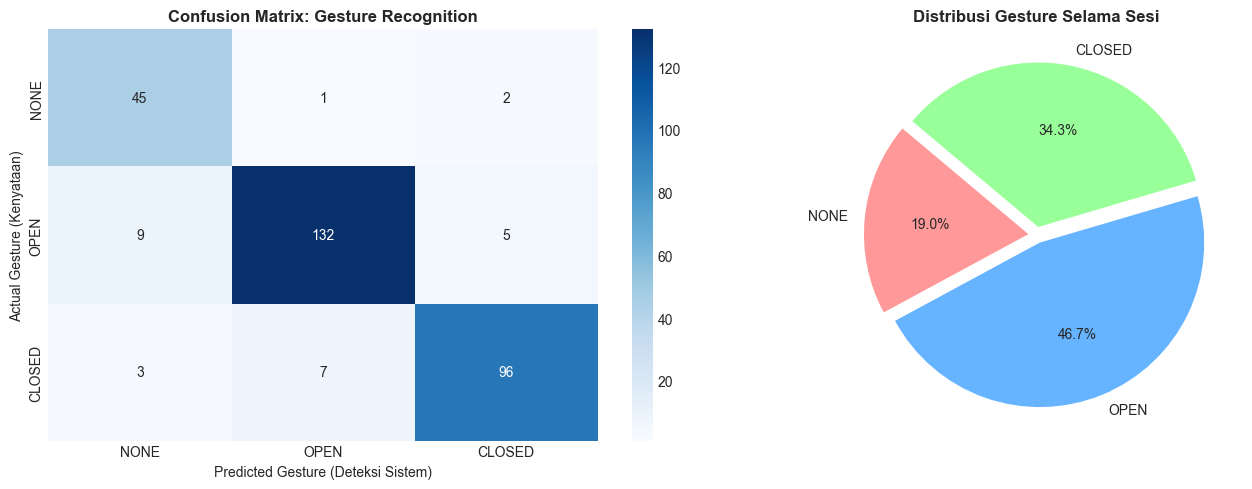

In [13]:
# Menghitung Metrik Evaluasi
acc = accuracy_score(ground_truth, predicted)
prec = precision_score(ground_truth, predicted, average='weighted', zero_division=0)
rec = recall_score(ground_truth, predicted, average='weighted', zero_division=0)
f1 = f1_score(ground_truth, predicted, average='weighted', zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}\n")

fig_cv, axs_cv = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(ground_truth, predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs_cv[0],
            xticklabels=['NONE', 'OPEN', 'CLOSED'], yticklabels=['NONE', 'OPEN', 'CLOSED'])
axs_cv[0].set_title("Confusion Matrix: Gesture Recognition", fontweight='bold')
axs_cv[0].set_xlabel("Predicted Gesture (Deteksi Sistem)")
axs_cv[0].set_ylabel("Actual Gesture (Kenyataan)")

# Distribusi Gesture
unique_gestures, counts_gestures = np.unique(predicted, return_counts=True)
label_pie = [labels_map[u] for u in unique_gestures]
axs_cv[1].pie(counts_gestures, labels=label_pie, autopct='%1.1f%%', 
              colors=['#ff9999','#66b3ff','#99ff99'], startangle=140, explode=[0.05]*len(label_pie))
axs_cv[1].set_title("Distribusi Gesture Selama Sesi", fontweight='bold')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

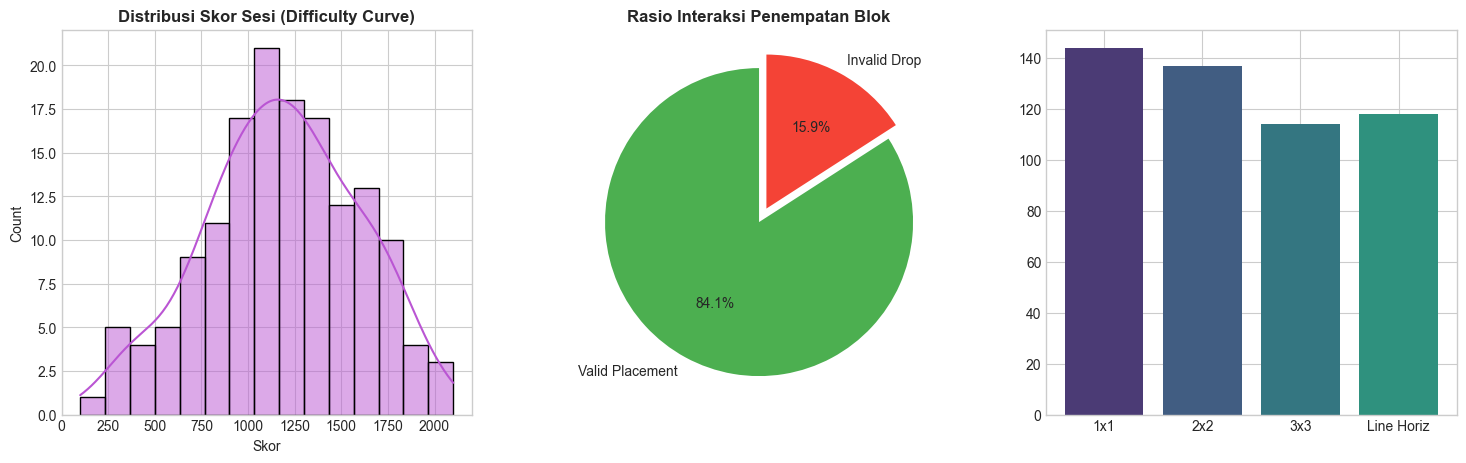

In [14]:
fig_game, axs_game = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Skor
sns.histplot(kumpulan_skor, bins=15, kde=True, color='mediumorchid', ax=axs_game[0])
axs_game[0].set_title("Distribusi Skor Sesi (Difficulty Curve)", fontweight='bold')
axs_game[0].set_xlabel("Skor")

# Valid vs Invalid Drop
axs_game[1].pie([total_valid_drop, total_invalid_drop], labels=['Valid Placement', 'Invalid Drop'],
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90, explode=[0, 0.1])
axs_game[1].set_title("Rasio Interaksi Penempatan Blok", fontweight='bold')

# Distribusi Kategori Blok
sns.barplot(x=nama_blok, y=frekuensi_blok, palette='viridis', ax=axs_game[2], hue=nama_blok, legend=False)
axs_game[2].set_title("Frekuensi Kemunculan Kategori Blok", fontweight='bold')
axs_game[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

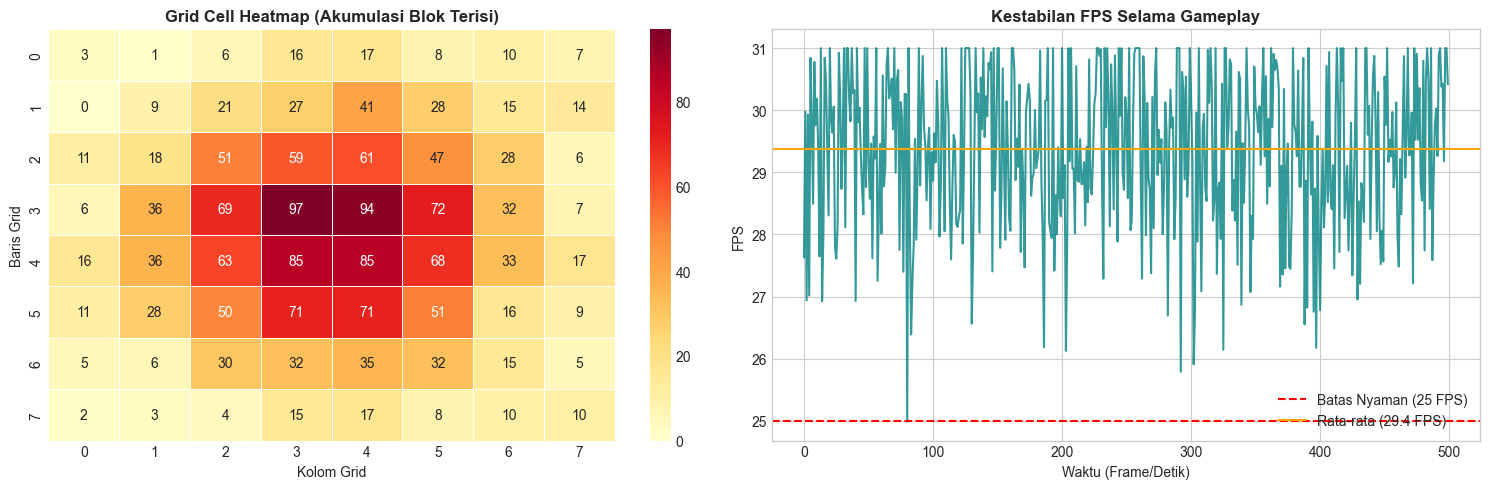

In [ ]:
fig_tech, axs_tech = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap 8x8 Grid
sns.heatmap(grid_akumulasi, annot=True, fmt="d", cmap="YlOrRd", ax=axs_tech[0], cbar=True, linewidths=.5)
axs_tech[0].set_title("Grid Cell Heatmap (Akumulasi Blok Terisi)", fontweight='bold')
axs_tech[0].set_xlabel("Kolom Grid")
axs_tech[0].set_ylabel("Baris Grid")

# Kestabilan FPS
axs_tech[1].plot(log_fps, color='teal', linewidth=1.5, alpha=0.8)
axs_tech[1].axhline(y=25, color='red', linestyle='--', label='Batas Nyaman (25 FPS)')
axs_tech[1].axhline(y=np.mean(log_fps), color='orange', linestyle='-', label=f'Rata-rata ({np.mean(log_fps):.1f} FPS)')
axs_tech[1].set_title("Kestabilan FPS Selama Gameplay", fontweight='bold')
axs_tech[1].set_xlabel("Waktu (Frame/Detik)")
axs_tech[1].set_ylabel("FPS")
axs_tech[1].legend()

plt.tight_layout()
plt.show()